# Project 4: Safe Reinforcement Learning with Constrained Optimization

**Author:** Milan Amrut Joshi

## Overview
This notebook implements **Safe RL** in a grid world with dangerous zones.
We compare:
1. **Standard Q-Learning:** Maximizes reward, ignoring safety constraints
2. **Lagrangian Q-Learning:** Incorporates safety constraints via Lagrangian relaxation

The goal is to reach a target while avoiding dangerous cells, subject to a
constraint on the cumulative cost (visits to dangerous zones).

$$\max_\pi \mathbb{E}[\sum_t \gamma^t r_t] \quad \text{s.t.} \quad \mathbb{E}[\sum_t \gamma^t c_t] \leq d$$

where $c_t$ is the cost at time $t$ and $d$ is the cost threshold.

## 1. Constrained MDP Framework

### Standard (Unconstrained) MDP
$$\pi^* = \arg\max_\pi \mathbb{E}_\pi \left[\sum_{t=0}^\infty \gamma^t r(s_t, a_t)\right]$$

### Constrained MDP (CMDP)
$$\pi^* = \arg\max_\pi \mathbb{E}_\pi \left[\sum_{t=0}^\infty \gamma^t r_t\right] \quad \text{subject to} \quad \mathbb{E}_\pi \left[\sum_{t=0}^\infty \gamma^t c_t\right] \leq d$$

### Lagrangian Relaxation
Convert the constrained problem to an unconstrained one:

$$\mathcal{L}(\pi, \lambda) = \mathbb{E}_\pi \left[\sum_t \gamma^t r_t\right] - \lambda \left(\mathbb{E}_\pi \left[\sum_t \gamma^t c_t\right] - d\right)$$

The Lagrange multiplier $\lambda \geq 0$ is updated via dual gradient ascent:

$$\lambda \leftarrow \max(0, \lambda + \eta_\lambda (\hat{C} - d))$$

where $\hat{C}$ is the observed episode cost and $d$ is the threshold.

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Grid world configuration
GRID_H = 8
GRID_W = 8
START = (0, 0)
GOAL = (7, 7)
COST_THRESHOLD = 2.0     # Maximum allowed cumulative cost

# Actions: up, down, left, right
NUM_ACTIONS = 4
ACTION_NAMES = ['Up', 'Down', 'Left', 'Right']
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# Training parameters
NUM_EPISODES = 3000
ALPHA = 0.2
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.998

print("Safe RL Grid World Configuration:")
print(f"  Grid: {GRID_H}x{GRID_W}")
print(f"  Start: {START}, Goal: {GOAL}")
print(f"  Cost threshold: {COST_THRESHOLD}")

Safe RL Grid World Configuration:
  Grid: 8x8
  Start: (0, 0), Goal: (7, 7)
  Cost threshold: 2.0


## 3. Grid World with Dangerous Zones

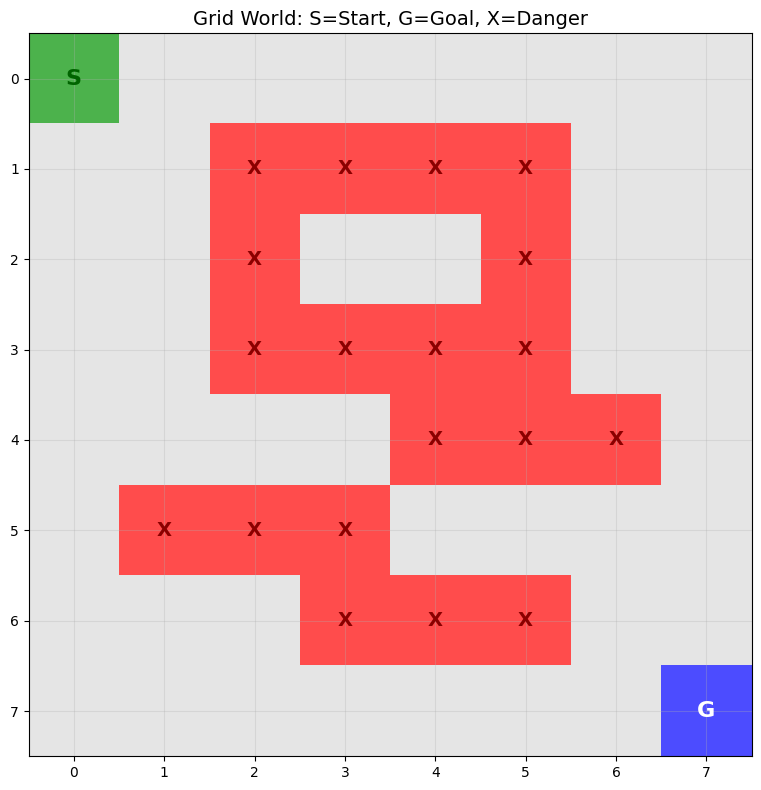

In [2]:
class SafeGridWorld:
    """Grid world with reward and cost (danger) signals."""

    def __init__(self, grid_h=GRID_H, grid_w=GRID_W):
        self.grid_h = grid_h
        self.grid_w = grid_w

        # Define danger zones (cost = 1 when visited)
        self.danger_map = np.zeros((grid_h, grid_w))
        # Create a dangerous corridor
        danger_cells = [
            (1, 2), (1, 3), (1, 4), (1, 5),
            (2, 2), (2, 5),
            (3, 2), (3, 3), (3, 4), (3, 5),
            (4, 4), (4, 5), (4, 6),
            (5, 1), (5, 2), (5, 3),
            (6, 3), (6, 4), (6, 5),
        ]
        for r, c in danger_cells:
            self.danger_map[r, c] = 1.0

        # Reward: -0.1 per step, +10 at goal, bonus for approaching goal
        self.goal = GOAL

    def reset(self):
        self.state = START
        return self.state

    def step(self, action):
        r, c = self.state
        dr, dc = MOVES[action]
        nr, nc = r + dr, c + dc

        # Check boundaries
        if 0 <= nr < self.grid_h and 0 <= nc < self.grid_w:
            self.state = (nr, nc)
        # else stay in place

        reward = -0.1
        cost = self.danger_map[self.state[0], self.state[1]]
        done = (self.state == self.goal)
        if done:
            reward = 10.0

        return self.state, reward, cost, done


env = SafeGridWorld()

# Visualize the grid
fig, ax = plt.subplots(figsize=(8, 8))
grid_display = np.zeros((GRID_H, GRID_W, 3))

for r in range(GRID_H):
    for c in range(GRID_W):
        if env.danger_map[r, c] > 0:
            grid_display[r, c] = [1.0, 0.3, 0.3]  # Red for danger
        else:
            grid_display[r, c] = [0.9, 0.9, 0.9]  # Light gray for safe

# Mark start and goal
grid_display[START[0], START[1]] = [0.3, 0.7, 0.3]  # Green for start
grid_display[GOAL[0], GOAL[1]] = [0.3, 0.3, 1.0]    # Blue for goal

ax.imshow(grid_display, origin='upper')
for r in range(GRID_H):
    for c in range(GRID_W):
        if env.danger_map[r, c] > 0:
            ax.text(c, r, 'X', ha='center', va='center', fontsize=14, color='darkred', fontweight='bold')
        if (r, c) == START:
            ax.text(c, r, 'S', ha='center', va='center', fontsize=16, color='darkgreen', fontweight='bold')
        if (r, c) == GOAL:
            ax.text(c, r, 'G', ha='center', va='center', fontsize=16, color='white', fontweight='bold')

ax.set_title('Grid World: S=Start, G=Goal, X=Danger', fontsize=14)
ax.set_xticks(range(GRID_W))
ax.set_yticks(range(GRID_H))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Standard Q-Learning (Ignores Constraints)

In [3]:
class StandardQLearning:
    """Standard Q-learning that maximizes reward only."""

    def __init__(self, grid_h, grid_w, num_actions):
        self.q_table = np.zeros((grid_h, grid_w, num_actions))
        self.num_actions = num_actions

    def get_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(self.num_actions)
        return np.argmax(self.q_table[state[0], state[1]])

    def update(self, state, action, reward, next_state, done, alpha=ALPHA, gamma=GAMMA):
        r, c = state
        nr, nc = next_state
        target = reward + (0 if done else gamma * np.max(self.q_table[nr, nc]))
        self.q_table[r, c, action] += alpha * (target - self.q_table[r, c, action])


# Train standard Q-learning
std_agent = StandardQLearning(GRID_H, GRID_W, NUM_ACTIONS)
std_rewards = []
std_costs = []
epsilon = EPSILON_START

for ep in range(NUM_EPISODES):
    state = env.reset()
    ep_reward = 0.0
    ep_cost = 0.0

    for step in range(200):
        action = std_agent.get_action(state, epsilon)
        next_state, reward, cost, done = env.step(action)
        std_agent.update(state, action, reward, next_state, done)
        ep_reward += reward
        ep_cost += cost
        state = next_state
        if done:
            break

    std_rewards.append(ep_reward)
    std_costs.append(ep_cost)
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

print(f"Standard Q-Learning complete.")
print(f"  Mean reward (last 500): {np.mean(std_rewards[-500:]):.3f}")
print(f"  Mean cost (last 500): {np.mean(std_costs[-500:]):.3f}")
print(f"  Cost threshold: {COST_THRESHOLD}")

Standard Q-Learning complete.
  Mean reward (last 500): 8.624
  Mean cost (last 500): 6.180
  Cost threshold: 2.0


## 5. Lagrangian Q-Learning (Safety-Constrained)

The Lagrangian approach modifies the effective reward:

$$r_{\text{eff}}(s, a) = r(s, a) - \lambda \cdot c(s, a)$$

The multiplier $\lambda$ increases when the cost exceeds the threshold and decreases otherwise.

In [4]:
class LagrangianQLearning:
    """Q-learning with Lagrangian constraint for safe RL."""

    def __init__(self, grid_h, grid_w, num_actions, cost_threshold):
        self.q_table = np.zeros((grid_h, grid_w, num_actions))
        self.q_cost = np.zeros((grid_h, grid_w, num_actions))  # Cost Q-function
        self.num_actions = num_actions
        self.lam = 0.0                   # Lagrange multiplier
        self.cost_threshold = cost_threshold
        self.lr_lambda = 0.05            # Learning rate for lambda

    def get_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(self.num_actions)
        r, c = state
        # Effective Q = Q_reward - lambda * Q_cost
        effective_q = self.q_table[r, c] - self.lam * self.q_cost[r, c]
        return np.argmax(effective_q)

    def update(self, state, action, reward, cost, next_state, done,
               alpha=ALPHA, gamma=GAMMA):
        r, c = state
        nr, nc = next_state

        # Update reward Q-function
        target_r = reward + (0 if done else gamma * np.max(self.q_table[nr, nc]))
        self.q_table[r, c, action] += alpha * (target_r - self.q_table[r, c, action])

        # Update cost Q-function
        target_c = cost + (0 if done else gamma * np.max(self.q_cost[nr, nc]))
        self.q_cost[r, c, action] += alpha * (target_c - self.q_cost[r, c, action])

    def update_lambda(self, episode_cost):
        """Dual gradient ascent on the Lagrange multiplier."""
        self.lam = max(0.0, self.lam + self.lr_lambda * (episode_cost - self.cost_threshold))


# Train Lagrangian Q-learning
lag_agent = LagrangianQLearning(GRID_H, GRID_W, NUM_ACTIONS, COST_THRESHOLD)
lag_rewards = []
lag_costs = []
lag_lambdas = []
epsilon = EPSILON_START

for ep in range(NUM_EPISODES):
    state = env.reset()
    ep_reward = 0.0
    ep_cost = 0.0

    for step in range(200):
        action = lag_agent.get_action(state, epsilon)
        next_state, reward, cost, done = env.step(action)
        lag_agent.update(state, action, reward, cost, next_state, done)
        ep_reward += reward
        ep_cost += cost
        state = next_state
        if done:
            break

    # Update Lagrange multiplier
    lag_agent.update_lambda(ep_cost)

    lag_rewards.append(ep_reward)
    lag_costs.append(ep_cost)
    lag_lambdas.append(lag_agent.lam)
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

print(f"Lagrangian Q-Learning complete.")
print(f"  Mean reward (last 500): {np.mean(lag_rewards[-500:]):.3f}")
print(f"  Mean cost (last 500): {np.mean(lag_costs[-500:]):.3f}")
print(f"  Final lambda: {lag_agent.lam:.4f}")

Lagrangian Q-Learning complete.
  Mean reward (last 500): -19.227
  Mean cost (last 500): 0.020
  Final lambda: 64.5500


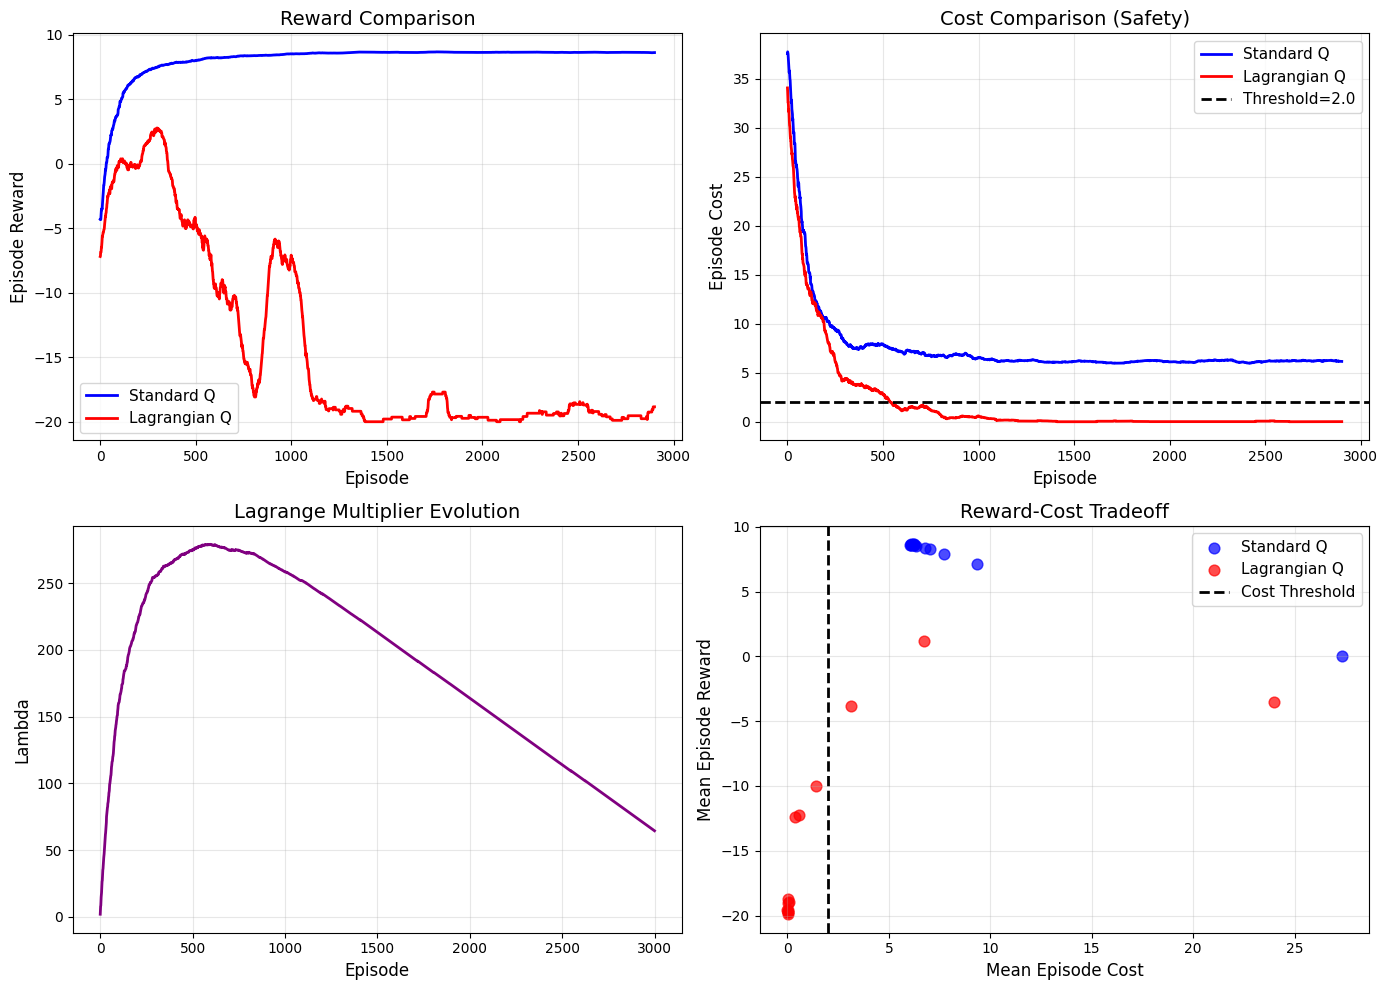

In [5]:
# Compare training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def smooth(data, w=100):
    return np.convolve(data, np.ones(w)/w, mode='valid')

# Rewards
axes[0][0].plot(smooth(std_rewards), 'b-', linewidth=2, label='Standard Q')
axes[0][0].plot(smooth(lag_rewards), 'r-', linewidth=2, label='Lagrangian Q')
axes[0][0].set_xlabel('Episode', fontsize=12)
axes[0][0].set_ylabel('Episode Reward', fontsize=12)
axes[0][0].set_title('Reward Comparison', fontsize=14)
axes[0][0].legend(fontsize=11)
axes[0][0].grid(True, alpha=0.3)

# Costs
axes[0][1].plot(smooth(std_costs), 'b-', linewidth=2, label='Standard Q')
axes[0][1].plot(smooth(lag_costs), 'r-', linewidth=2, label='Lagrangian Q')
axes[0][1].axhline(y=COST_THRESHOLD, color='k', linestyle='--', linewidth=2, label=f'Threshold={COST_THRESHOLD}')
axes[0][1].set_xlabel('Episode', fontsize=12)
axes[0][1].set_ylabel('Episode Cost', fontsize=12)
axes[0][1].set_title('Cost Comparison (Safety)', fontsize=14)
axes[0][1].legend(fontsize=11)
axes[0][1].grid(True, alpha=0.3)

# Lambda evolution
axes[1][0].plot(lag_lambdas, 'purple', linewidth=2)
axes[1][0].set_xlabel('Episode', fontsize=12)
axes[1][0].set_ylabel('Lambda', fontsize=12)
axes[1][0].set_title('Lagrange Multiplier Evolution', fontsize=14)
axes[1][0].grid(True, alpha=0.3)

# Reward-cost tradeoff scatter
window = 200
std_r_bins = [np.mean(std_rewards[i:i+window]) for i in range(0, len(std_rewards)-window, window)]
std_c_bins = [np.mean(std_costs[i:i+window]) for i in range(0, len(std_costs)-window, window)]
lag_r_bins = [np.mean(lag_rewards[i:i+window]) for i in range(0, len(lag_rewards)-window, window)]
lag_c_bins = [np.mean(lag_costs[i:i+window]) for i in range(0, len(lag_costs)-window, window)]

axes[1][1].scatter(std_c_bins, std_r_bins, c='blue', s=60, alpha=0.7, label='Standard Q')
axes[1][1].scatter(lag_c_bins, lag_r_bins, c='red', s=60, alpha=0.7, label='Lagrangian Q')
axes[1][1].axvline(x=COST_THRESHOLD, color='k', linestyle='--', linewidth=2, label='Cost Threshold')
axes[1][1].set_xlabel('Mean Episode Cost', fontsize=12)
axes[1][1].set_ylabel('Mean Episode Reward', fontsize=12)
axes[1][1].set_title('Reward-Cost Tradeoff', fontsize=14)
axes[1][1].legend(fontsize=11)
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualize Safe vs Unsafe Paths

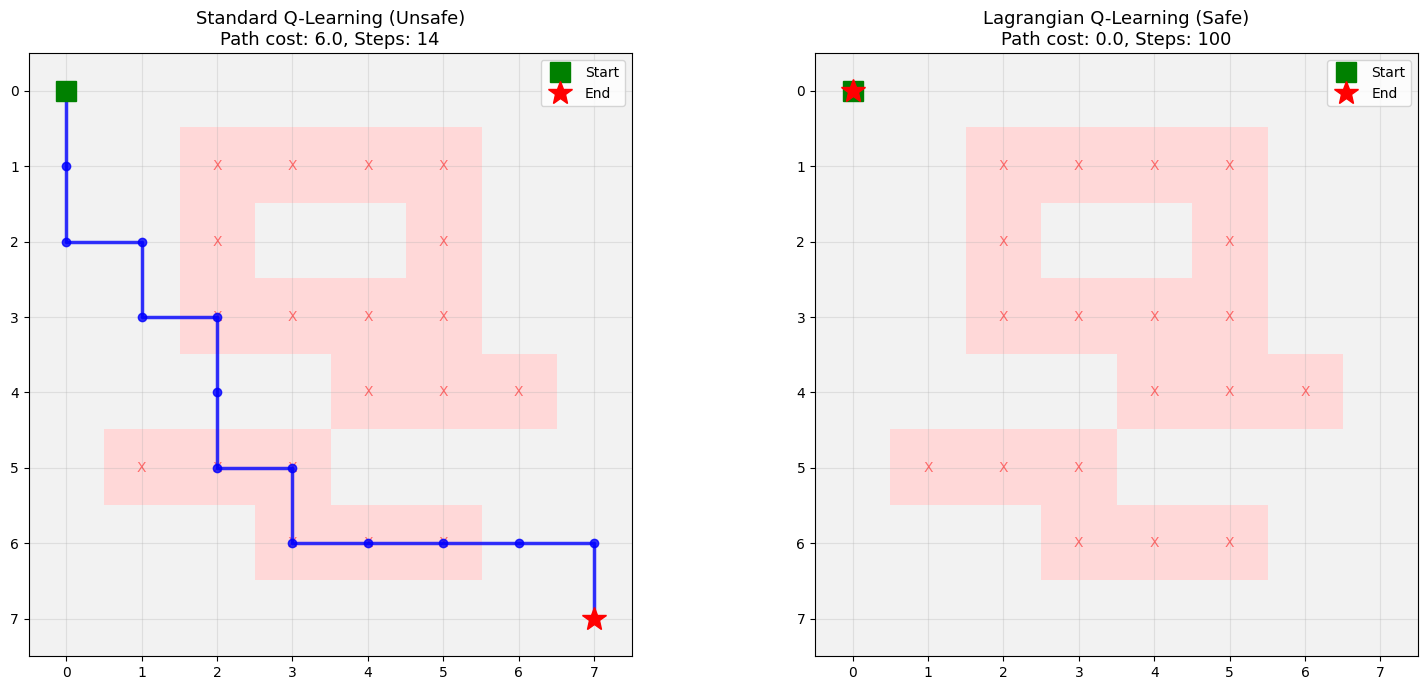

In [6]:
def extract_path(env, agent, max_steps=100, use_lagrangian=False):
    """Extract the greedy path from start to goal."""
    state = env.reset()
    path = [state]
    total_cost = 0.0
    for _ in range(max_steps):
        if use_lagrangian:
            action = agent.get_action(state, epsilon=0.0)
        else:
            action = agent.get_action(state, epsilon=0.0)
        next_state, reward, cost, done = env.step(action)
        path.append(next_state)
        total_cost += cost
        state = next_state
        if done:
            break
    return path, total_cost


std_path, std_path_cost = extract_path(env, std_agent)
lag_path, lag_path_cost = extract_path(env, lag_agent, use_lagrangian=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, path, path_cost, title in [
    (axes[0], std_path, std_path_cost, 'Standard Q-Learning (Unsafe)'),
    (axes[1], lag_path, lag_path_cost, 'Lagrangian Q-Learning (Safe)')
]:
    # Draw grid
    grid_display = np.zeros((GRID_H, GRID_W, 3))
    for r in range(GRID_H):
        for c in range(GRID_W):
            if env.danger_map[r, c] > 0:
                grid_display[r, c] = [1.0, 0.85, 0.85]
            else:
                grid_display[r, c] = [0.95, 0.95, 0.95]

    ax.imshow(grid_display, origin='upper')

    # Draw danger zones
    for r in range(GRID_H):
        for c in range(GRID_W):
            if env.danger_map[r, c] > 0:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=10,
                       color='red', alpha=0.5)

    # Draw path
    path_arr = np.array(path)
    ax.plot(path_arr[:, 1], path_arr[:, 0], 'b-o', markersize=6, linewidth=2.5,
           alpha=0.8, zorder=5)
    ax.plot(path_arr[0, 1], path_arr[0, 0], 'gs', markersize=15, zorder=6, label='Start')
    ax.plot(path_arr[-1, 1], path_arr[-1, 0], 'r*', markersize=18, zorder=6, label='End')

    ax.set_title(f'{title}\nPath cost: {path_cost:.1f}, Steps: {len(path)-1}', fontsize=13)
    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(GRID_H - 0.5, -0.5)
    ax.set_xticks(range(GRID_W))
    ax.set_yticks(range(GRID_H))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 7. Constraint Satisfaction Analysis

=== Constraint Satisfaction (threshold=2.0) ===
Standard Q: mean cost=6.000, violation rate=1.000
Lagrangian Q: mean cost=0.000, violation rate=0.000


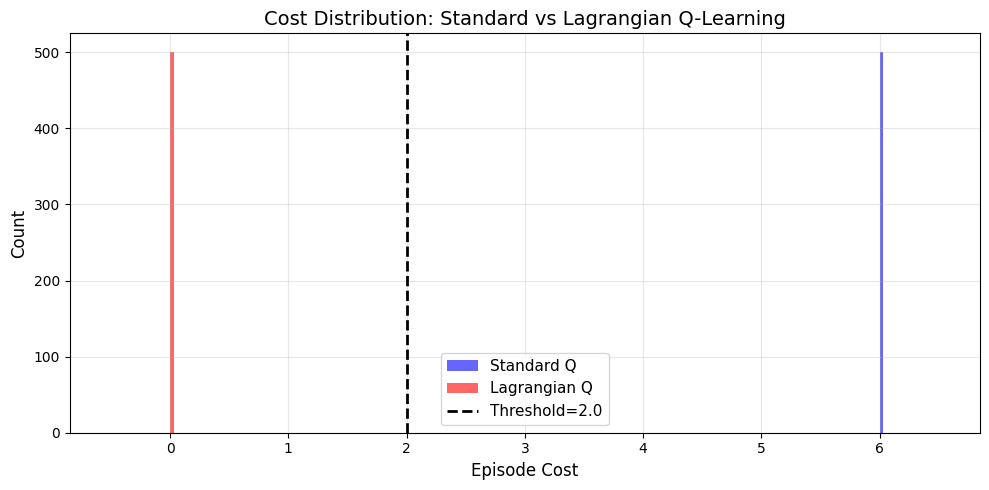

In [7]:
# Run many test episodes and check constraint satisfaction
num_test = 500
std_test_costs = []
lag_test_costs = []

for _ in range(num_test):
    # Standard Q
    state = env.reset()
    cost_sum = 0.0
    for step in range(200):
        action = std_agent.get_action(state, epsilon=0.0)
        next_state, _, cost, done = env.step(action)
        cost_sum += cost
        state = next_state
        if done:
            break
    std_test_costs.append(cost_sum)

    # Lagrangian Q
    state = env.reset()
    cost_sum = 0.0
    for step in range(200):
        action = lag_agent.get_action(state, epsilon=0.0)
        next_state, _, cost, done = env.step(action)
        cost_sum += cost
        state = next_state
        if done:
            break
    lag_test_costs.append(cost_sum)

std_violation_rate = np.mean(np.array(std_test_costs) > COST_THRESHOLD)
lag_violation_rate = np.mean(np.array(lag_test_costs) > COST_THRESHOLD)

print(f"=== Constraint Satisfaction (threshold={COST_THRESHOLD}) ===")
print(f"Standard Q: mean cost={np.mean(std_test_costs):.3f}, violation rate={std_violation_rate:.3f}")
print(f"Lagrangian Q: mean cost={np.mean(lag_test_costs):.3f}, violation rate={lag_violation_rate:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(std_test_costs, bins=30, alpha=0.6, label='Standard Q', color='blue')
ax.hist(lag_test_costs, bins=30, alpha=0.6, label='Lagrangian Q', color='red')
ax.axvline(x=COST_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold={COST_THRESHOLD}')
ax.set_xlabel('Episode Cost', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Cost Distribution: Standard vs Lagrangian Q-Learning', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

This notebook demonstrated Safe RL using constrained optimization:

1. **Standard Q-Learning** finds the shortest path but may traverse dangerous zones
2. **Lagrangian Q-Learning** learns to avoid danger by incorporating cost constraints
3. The Lagrange multiplier **automatically adjusts** the safety-reward tradeoff
4. Constraint satisfaction analysis shows the Lagrangian approach respects the cost budget

Key takeaways:
- Safety constraints are critical in real-world RL (robotics, healthcare, autonomous driving)
- The Lagrangian approach is simple yet effective for constrained MDPs
- The lambda update rule provides an adaptive mechanism for balancing reward and safety
- There is an inherent tradeoff: safer policies may achieve lower reward